# Machine Learning Final Project : Ingredient Classification
**Logan Dawes** - CS4783

The goal of this project is to develop a machine learning model for both classification and prediction tasks. The model will be designed to automatically infer missing ingredient lists and nutrient information for a given food item. This enables it to perform ingredient classification as well as nutrient estimation

### Import Libraries

In [11]:
%reset -f

In [ ]:
# Import data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import other libraries
import json
import gc

# Import TensorFlow and Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Input
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

### Load Cleaned Dataset

First we will load the cleaned and prepared data from the EDA & Feature Engineering notebook.

For this model, we will load the ingredient one-hot encoded columns as the ones to classify.

For the sake of demonstration, we will only attempt to classify columns that are more than 99% missing, due to the very sparse data.

For better model performance, we will also drop nutrient amounts that are more than 90% zero.

In [14]:
# Load datatypes for final_food_data
with open('final_food_data_dtypes.json', 'r') as f:
    final_food_data_dtypes = json.load(f)

# Load processed dataset
food_data = pd.read_csv('final_food_data.csv', dtype=final_food_data_dtypes)


# Select all one-hot ingredient columns as targets
ingredient_oh_cols = [col for col in food_data.columns if col.startswith('ingredient_oh_')]
print(f'Ingredient one-hot columns: {ingredient_oh_cols[:10]} ... total: {len(ingredient_oh_cols)}')

# Drop ingredient one-hot columns with >99% zeros
ingredient_oh_cols = [
    col for col in ingredient_oh_cols
    if (food_data[col] == 0).mean() <= 0.99
]
print(f'Filtered ingredient one-hot columns: {ingredient_oh_cols[:10]} ... total: {len(ingredient_oh_cols)}')

# Select all nutrient amount columns (exclude logs and package weight)
nutrient_candidates = [col for col in food_data.columns if 'amount' in col and not col.endswith('_log') and not col == 'package_weight_amount']
print('Zero percentage for each nutrient candidate:')
nutrient_cols = []
for col in nutrient_candidates:
    zero_pct = (food_data[col] == 0).mean() * 100
    print(f'{col}: {zero_pct:.2f}% zero')
    if zero_pct <= 90:
        nutrient_cols.append(col)

# Drop failed nutrient candidates from feature columns
failed_nutrient_cols = [col for col in nutrient_candidates if col not in nutrient_cols]

Ingredient one-hot columns: ['ingredient_oh_salt', 'ingredient_oh_sugar', 'ingredient_oh_water', 'ingredient_oh_citricAcid', 'ingredient_oh_cornSyrup', 'ingredient_oh_naturalFlavor', 'ingredient_oh_soyLecithin', 'ingredient_oh_seaSalt', 'ingredient_oh_natural', 'ingredient_oh_dextrose'] ... total: 500
Filtered ingredient one-hot columns: ['ingredient_oh_salt', 'ingredient_oh_sugar', 'ingredient_oh_water', 'ingredient_oh_citricAcid', 'ingredient_oh_cornSyrup', 'ingredient_oh_naturalFlavor', 'ingredient_oh_soyLecithin', 'ingredient_oh_seaSalt', 'ingredient_oh_natural', 'ingredient_oh_dextrose'] ... total: 167
Zero percentage for each nutrient candidate:
Acetic acid amount: 100.00% zero
Alanine amount: 99.98% zero
Alcohol, ethyl amount: 100.00% zero
Arginine amount: 99.98% zero
Ash amount: 99.82% zero
Aspartic acid amount: 99.98% zero
Beta-glucans amount: 100.00% zero
Biotin amount: 99.80% zero
Caffeine amount: 99.96% zero
Calcium, Ca amount: 44.51% zero
Carbohydrate, by difference amount

### Prepare input features
Differs from nutrient regression by having the ingredient encoded columns as the target.

In [15]:
# Prepare input features (exclude ingredient one-hot columns)
exclude_cols = set(ingredient_oh_cols)
feature_cols = [col for col in food_data.columns if col not in exclude_cols and col not in set(failed_nutrient_cols)]

# Memory cleanup after data loading
def memory_cleanup(data):
    for var in data:
        if var in locals():
            del globals()[var]
    gc.collect()
    
memory_cleanup(['final_food_data_dtypes', 'f', 'exclude_cols'])

In [16]:
# Drop highly correlated features
correlation_threshold = 0.95
corr_matrix = food_data[feature_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > correlation_threshold)]
print(f'Dropping {len(to_drop)} highly correlated features: {to_drop[:10]} ...')
feature_cols = [col for col in feature_cols if col not in to_drop]
memory_cleanup(['corr_matrix', 'upper_tri', 'to_drop'])

Dropping 2 highly correlated features: ['Iron, Fe amount_log', 'brand_encoded'] ...


## Step 1: Train/Test Split

Before preparing the train and test split for the data, we will define a batch generator function that will load a batch of data into the model. This is for memory efficiency.

In [17]:
# Batch generator for memory-efficient training
def batch_generator(data, feature_cols, ingredient_oh_cols, window_size=3, batch_size=128):
    num_rows = len(data)
    while True:
        for start in range(window_size, num_rows, batch_size):
            end = min(start + batch_size, num_rows)
            X_batch = []
            y_batch = []
            for i in range(start, end):
                X_window = data.iloc[i-window_size:i][feature_cols].values
                y_row = data.iloc[i][ingredient_oh_cols].values
                X_batch.append(X_window)
                y_batch.append(y_row)
            yield np.array(X_batch), np.array(y_batch)

Now, the following code calculates the split index for an 80/20 train/test split, accounting for the window size used in the batch generator.

 It then creates memory-efficient batch generators for both the training and testing sets, which will be used to feed data into the model during training and evaluation.
 
  The code also computes the number of steps per epoch for both sets, ensuring that the model trains and validates on the correct number of batches.

In [18]:
# Set window size and batch size
window_size = 3
batch_size = 128

# Calculate split index for train/test
num_rows = len(food_data)
split_idx = int((num_rows - window_size) * 0.8)
print(f'[Split] Total rows: {num_rows}, Train rows: {split_idx + window_size}, Test rows: {num_rows - split_idx}')

# Define train and test generators
train_gen = batch_generator(
    food_data.iloc[:split_idx + window_size],
    feature_cols,
    ingredient_oh_cols,
    window_size=window_size,
    batch_size=batch_size
)
test_gen = batch_generator(
    food_data.iloc[split_idx:],
    feature_cols,
    ingredient_oh_cols,
    window_size=window_size,
    batch_size=batch_size
)

# Calculate steps per epoch
train_steps = (split_idx) // batch_size
test_steps = (num_rows - window_size - split_idx) // batch_size
print(f'[Steps] Train steps per epoch: {train_steps}, Test steps: {test_steps}')

[Split] Total rows: 1977398, Train rows: 1581919, Test rows: 395482
[Steps] Train steps per epoch: 12358, Test steps: 3089


## Step 2: Build the Model

### Explanation of LSTM Model Architecture

The `make_lstm_model` function builds a neural network for multi-label ingredient classification using the following layers and techniques:

**Why LSTM?**  
LSTM (Long Short-Term Memory) networks are designed to capture temporal dependencies in sequential data. In this project, food ingredient and nutrient information can have patterns over ordered samples. LSTMs are well-suited for learning these relationships, making them a good choice for modeling sequences where past context influences predictions.

**Window Size Meaning:**  
The window size determines how many consecutive samples are fed into the model at once. Here, a window size of 3 means the model considers the current sample and the previous two samples together, allowing it to learn short-term trends and dependencies in the input features that may affect ingredient classification.

**1. Input Layer:**
- Specifies the input shape as `(window_size, feature_count)`, allowing the model to process sequences of features.

**2. LSTM Layers:**
- The first LSTM layer (`units_1`) captures temporal dependencies in the input sequence and outputs a sequence for further processing.
- The second LSTM layer (`units_2`) processes the output from the first LSTM and returns a single vector, summarizing the learned sequence features.

**3. Dropout Layers:**
- Dropout (`dropout_1` and `dropout_2`) randomly sets a fraction of input units to zero during training, helping prevent overfitting by making the model less sensitive to specific weights.

**4. Batch Normalization:**
- Batch normalization normalizes the output of the previous layer, speeding up training and improving stability.

**5. Dense Output Layer:**
- The final dense layer outputs predictions for all ingredient targets. It uses L2 regularization (`kernel_regularizer=l2_reg`) to penalize large weights, further reducing overfitting.
- The activation function is `sigmoid`, which outputs values between 0 and 1 for each ingredient, suitable for multi-label classification.

**6. Optimizer and Loss Function:**
- The model uses the Adam optimizer, which adapts learning rates for each parameter and generally converges faster than standard gradient descent.
- The loss function is Binary Crossentropy (`binary_crossentropy`), which measures the difference between predicted probabilities and actual binary labels, making it appropriate for multi-label classification tasks.

Together, these layers and techniques allow the model to learn complex temporal and feature relationships in the data, while regularization and normalization help ensure generalization and stable training.

### Build the Model

In [ ]:
# Utility function to build and compile LSTM model
def make_lstm_model(window_size, feature_count, output_count, units_1, units_2, dropout_1, dropout_2, l2_reg, learning_rate):
    model = Sequential()
    model.add(Input(shape=(window_size, feature_count)))    # Input Layer
    model.add(LSTM(units=units_1, return_sequences=True))   # First LSTM Layer
    model.add(Dropout(dropout_1))                           # Dropout Layer
    model.add(BatchNormalization())                         # Batch Normalization Layer
    
    # Second pass of LSTM, Dropout, BatchNormalization
    model.add(LSTM(units=units_2))
    model.add(Dropout(dropout_2))
    model.add(BatchNormalization())
    
    # Final Dense layer for the output
    model.add(Dense(output_count, kernel_regularizer=l2_reg, activation='sigmoid')) # Activation changed to 'sigmoid' for binary classification
    
    # Adam optimizer
    adam_opt = Adam(learning_rate=learning_rate)
    model.compile(optimizer=adam_opt, loss='binary_crossentropy') # Loss function for binary classification
    return model

### KerasTuner Hyperparameter Search

KerasTuner was used previously to automate the search for optimal hyperparameters for the LSTM model. It tested different combinations of LSTM units, dropout rates, and learning rates to find the configuration that minimized validation loss.

It is now disabled to save time, the hyperparameters from the trials are used.

In [ ]:
'''
# Define a model-building function for KerasTuner
def build_lstm_model(hp):
    l2_reg = regularizers.l2(0.001)
    units_1 = hp.Int('units_1', min_value=32, max_value=128, step=32)
    units_2 = hp.Int('units_2', min_value=32, max_value=128, step=32)
    dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
    dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model = make_lstm_model(
        window_size,
        len(feature_cols),
        len(nutrient_cols),
        units_1,
        units_2,
        dropout_1,
        dropout_2,
        l2_reg,
        learning_rate
    )
    return model
'''

In [ ]:
'''
# Set up KerasTuner for hyperparameter search
tuner = kt.RandomSearch(
    build_lstm_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='kt_lstm_tuning',
    project_name='nutrient_lstm',
    overwrite=True,
    seed=42,
    )
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
print('[KerasTuner] Starting hyperparameter search...')
tuner.search(
    train_gen,
    steps_per_epoch=train_steps,
    validation_data=test_gen,
    validation_steps=test_steps,
    epochs=5,
    callbacks=[early_stop]
    )
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print('[KerasTuner] Best hyperparameters found:')
for param in best_hp.values.keys():
    print(f'{param}: {best_hp.get(param)}')'''

Best val_loss So Far: 321.3281555175781
Total elapsed time: 08h 56m 13s

Search: Running Trial #5

Value             |Best Value So Far |Hyperparameter

128               |32                |units_1

64                |96                |units_2

0.3               |0.2               |dropout_1

0.3               |0.2               |dropout_2

0.01              |0.001             |learning_rate

In [19]:
# Build the LSTM model for multi-output regression with L2 regularization using best hyperparameters from KerasTuner
l2_reg = regularizers.l2(0.001)
units_1 = 32
units_2 = 96
dropout_1 = 0.2
dropout_2 = 0.2
learning_rate = 0.001
print(f'[Model] Building LSTM model with input shape ({window_size}, {len(feature_cols)}) and output size {len(ingredient_oh_cols)}')
model = make_lstm_model(window_size, len(feature_cols), len(ingredient_oh_cols), units_1, units_2, dropout_1, dropout_2, l2_reg, learning_rate)

[Model] Building LSTM model with input shape (3, 473) and output size 167


## Step 3: Train the Model

Now we will train the model we have defined, for up to 20 epochs. We will define EarlyStopping, which allows the model to stop if it is not improving upon the loss function for 3 epochs. It will then revert to best weights.

This is optimal to prevent overfitting and save computation time.

In [ ]:
# Fit the model using the batch generator
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
print(f'[Training] Starting model.fit for up to 20 epochs, batch size {batch_size}, train steps {train_steps}, validation steps {test_steps}')
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    epochs=20,
    validation_data=test_gen,
    validation_steps=test_steps,
    callbacks=[early_stop]
)

Above cell data was accidentally cleared, this ran for 7 epochs for about 3 hours

In [ ]:
# Collect predictions and true values from test generator for classification calculation
y_true = []
y_pred = []
for batch_num in range(test_steps):
    X_batch, y_batch = next(test_gen)
    preds = model.predict(X_batch)
    y_true.append(y_batch)
    y_pred.append(preds)
    percent_complete = int(100 * (batch_num + 1) / test_steps)
    print(f'\n[Prediction] {percent_complete}%', end='\r')
    gc.collect()
y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━

## Step 4: Evaluate the Model

### Model Evaluation Metrics Explained

**Accuracy:**
- The proportion of correct predictions (both positive and negative) out of all predictions.
- Useful for balanced datasets, but can be misleading if classes are imbalanced.

**Recall (Sensitivity):**
- Measures the proportion of actual positives that were correctly identified by the model.
- High recall means most true positives are detected.

**Precision:**
- The proportion of predicted positives that are actually correct.
- High precision means few false positives.

**F1 Score:**
- The harmonic mean of precision and recall.
- Provides a balanced measure when classes are imbalanced or when both false positives and false negatives are important.

In [ ]:
# Evaluate accuracy, recall, precision, and f1 for each ingredient using sklearn metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

def get_classification_metrics(y_true, y_pred):
    accuracies = []
    recalls = []
    precisions = []
    f1s = []
    for i in range(y_true.shape[1]):
        y_true_bin = (y_true[:, i] >= 0.5).astype(int)
        y_pred_bin = (y_pred[:, i] >= 0.5).astype(int)
        accuracy = accuracy_score(y_true_bin, y_pred_bin)
        recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
        precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
        f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
        accuracies.append(accuracy)
        recalls.append(recall)
        precisions.append(precision)
        f1s.append(f1)
    return accuracies, f1s, recalls, precisions

accuracies, f1s, recalls, precisions = get_classification_metrics(y_true, y_pred)
for i in range(len(ingredient_oh_cols)):
    print(f'Ingredient: {ingredient_oh_cols[i]} - Accuracy: {accuracies[i]:.4f}, Recall: {recalls[i]:.4f}, Precision: {precisions[i]:.4f}, F1: {f1s[i]:.4f}')

Ingredient: ingredient_oh_salt - Accuracy: 0.5377, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_sugar - Accuracy: 0.6755, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_water - Accuracy: 0.6790, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_citricAcid - Accuracy: 0.8165, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_cornSyrup - Accuracy: 0.8937, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_naturalFlavor - Accuracy: 0.8598, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_soyLecithin - Accuracy: 0.8987, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_seaSalt - Accuracy: 0.8906, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_natural - Accuracy: 0.8942, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_dextrose - Accuracy: 0.9127, Recall: 0.0000, Precision: 0.0000, F1

In [23]:
# Print summary statistics for classification metrics
print('Classification Metrics Summary:')
print(f'Mean Accuracy: {np.mean(accuracies):.4f}')
print(f'Median Accuracy: {np.median(accuracies):.4f}')
print(f'Mean Recall: {np.mean(recalls):.4f}')
print(f'Median Recall: {np.median(recalls):.4f}')
print(f'Mean Precision: {np.mean(precisions):.4f}')
print(f'Median Precision: {np.median(precisions):.4f}')
print(f'Mean F1: {np.mean(f1s):.4f}')
print(f'Median F1: {np.median(f1s):.4f}')

Classification Metrics Summary:
Mean Accuracy: 0.9655
Median Accuracy: 0.9803
Mean Recall: 0.0000
Median Recall: 0.0000
Mean Precision: 0.0000
Median Precision: 0.0000
Mean F1: 0.0000
Median F1: 0.0000


### Evaluation Summary

- The model achieved very high accuracy (mean: 0.97), but recall, precision, and F1 scores are all zero.
- This indicates the model predicted all zeros (no ingredients present), which is a trivial solution given the class imbalance.
- High accuracy is misleading here, as the model failed to identify any true positives.
- Improvements are needed to address the extreme class imbalance and encourage the model to predict positive cases.

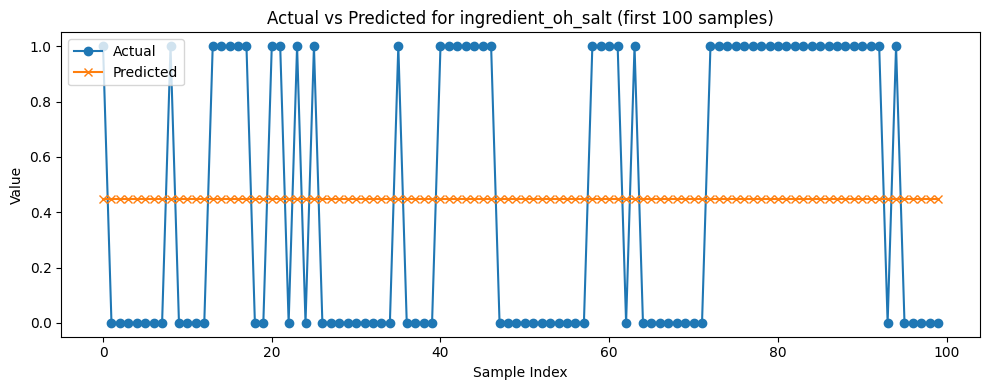

In [25]:
# Plot actual vs predicted for the first ingredient column
ingredient_idx = 0
plt.figure(figsize=(10, 4))
plt.plot(y_true[:100, ingredient_idx], label='Actual', marker='o')
plt.plot(y_pred[:100, ingredient_idx], label='Predicted', marker='x')
plt.title(f'Actual vs Predicted for {ingredient_oh_cols[ingredient_idx]} (first 100 samples)')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

### Conclusion:

Upon analysis of this model, it is clear that severe class imbalance in the ingredient labels prevents the model from predicting any true positives.

Class imbalance occurs when the number of samples for one class outweighs the number of samples for the other class. In this dataset, most ingredient columns are overwhelmingly zeros, so the model learns to always predict zero to minimize loss, resulting in high accuracy but poor recall and precision.

#### Addressing Class Imbalance in Future Work:

1. **Resampling Techniques:**
   - Oversampling: Increase the number of positive samples by duplicating minority class examples (like SMOTE).
   - Undersampling: Reduce the number of negative samples to balance the classes.

2. **Class Weights:**
   - Assign higher weights to the minority class in the loss function so that misclassifying positive cases is penalized more heavily. This encourages the model to pay more attention to rare ingredients.

3. **Threshold Tuning:**
   - Adjust the decision threshold for classifying an ingredient as present.

Adding these would be a way to improve the model to learn to identify rare ingredients and improve recall and precision.